In [1]:
from mvv_delay_tracker.realtime.data_loading import load_new_data
import pandas as pd

In [2]:
existing_data = pd.read_parquet("../data/realtime/mvv_realtime.parquet")

In [3]:
existing_data

,observation_timestamp,trip_id,start_date,trip_schedule_relationship,stop_schedule_relationship,line,agency_id,agency_name,stop_id,stop_name,stop_sequence,departure_time,departure_delay,arrival_time,arrival_delay,is_prediction
0,2026-09-11 11:54:56.088226,162984,20260911,SCHEDULED,SCHEDULED,55,58,Stadtwerke München,419463,Waldperlach (Süd),0,2026-09-11 10:54:41,11.0,NaT,NaN,True
1,2026-09-11 11:54:56.088226,162984,20260911,SCHEDULED,SCHEDULED,55,58,Stadtwerke München,665719,Waldperlach,1,2026-09-11 10:55:27,27.0,2026-09-11 10:55:04,4.0,False
2,2026-09-11 11:54:56.088226,162984,20260911,SCHEDULED,SCHEDULED,55,58,Stadtwerke München,519013,Waldheimplatz,2,2026-09-11 10:56:44,14.0,2026-09-11 10:56:16,-14.0,False
3,2026-09-11 11:54:56.088226,162984,20260911,SCHEDULED,SCHEDULED,55,58,Stadtwerke München,353226,Eulenspiegelstraße,3,2026-09-11 10:57:43,13.0,2026-09-11 10:57:18,-12.0,False
4,2026-09-11 11:54:56.088226,162984,20260911,SCHEDULED,SCHEDULED,55,58,Stadtwerke München,292300,Im Gefilde,4,2026-09-11 10:59:00,0.0,2026-09-11 10:58:35,-25.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262164,2026-09-15 10:10:35.331866,256354,20260915,SCHEDULED,SCHEDULED,13B,35,Aachener Straßenbahn,323686,Planegger Straße,7,2026-09-15 12:22:00,0.0,2026-09-15 12:22:00,0.0,True
262165,2026-09-15 10:10:35.331866,1485950,20260915,SCHEDULED,SCHEDULED,49,354,Omnipart,257512,Orleansstraße,15,2026-09-15 12:12:00,0.0,2026-09-15 12:12:00,0.0,True
262166,2026-09-15 10:10:35.331866,1459358,20260915,SCHEDULED,SCHEDULED,4,220,Hamburger Verkehrsverbund,373027,Gustav-Mahler-Straße,10,2026-09-15 09:41:11,-49.0,2026-09-15 09:41:11,-49.0,False
262167,2026-09-15 10:10:35.331866,1159776,20260915,SCHEDULED,SCHEDULED,736,166,Verkehrsverbund Pforzheim-Enzkreis,140242,St. Emmeram,2,2026-09-15 17:39:00,0.0,2026-09-15 17:39:00,0.0,True


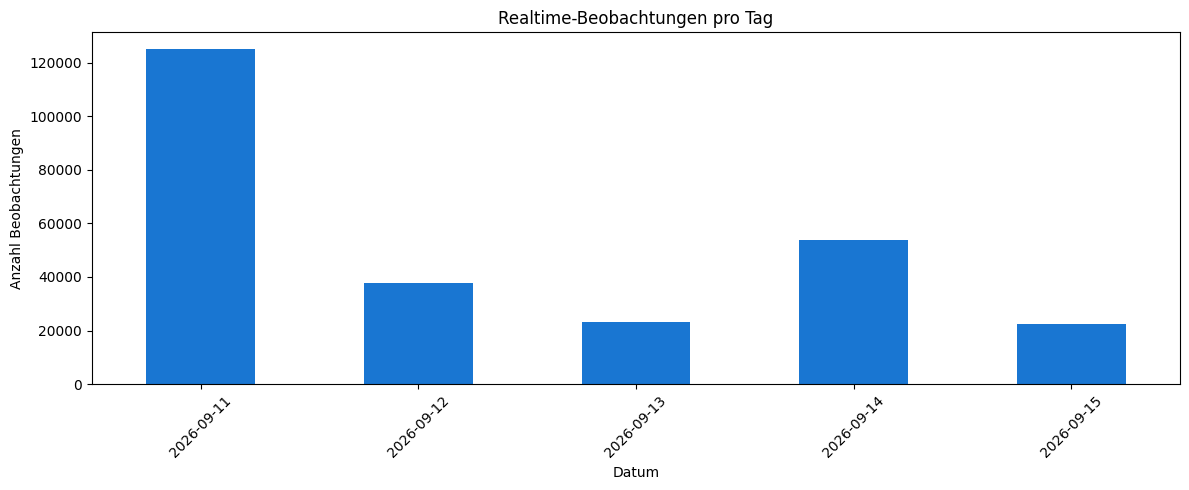

observation_date
2026-09-11    125065
2026-09-12     37917
2026-09-13     23094
2026-09-14     53826
2026-09-15     22267
Name: observations, dtype: int64

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

observations_per_day = (
    existing_data.assign(
        observation_date=pd.to_datetime(
            existing_data["observation_timestamp"],
            errors="coerce",
        ).dt.date
    )
    .dropna(subset=["observation_date"])
    .groupby("observation_date")
    .size()
    .rename("observations")
)

ax = observations_per_day.plot(
    kind="bar",
    figsize=(12, 5),
    color="#1976D2",
    title="Realtime-Beobachtungen pro Tag",
)
ax.set_xlabel("Datum")
ax.set_ylabel("Anzahl Beobachtungen")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

observations_per_day

In [5]:
september_11 = existing_data.loc[
    pd.to_datetime(existing_data["observation_timestamp"], errors="coerce").dt.date
    == pd.Timestamp("2026-09-11").date()
].copy()

old_key = ["trip_id", "start_date", "stop_id"]
current_key = [*old_key, "agency_id"]

old_key_counts = september_11.groupby(old_key, dropna=False).size()
current_key_counts = september_11.groupby(current_key, dropna=False).size()

duplicate_summary = pd.Series({
    "Zeilen am 11.09.": len(september_11),
    "Duplikatgruppen mit altem Schlüssel": int((old_key_counts > 1).sum()),
    "Duplikatzeilen mit altem Schlüssel": int(
        old_key_counts[old_key_counts > 1].sub(1).sum()
    ),
    "Duplikatgruppen mit aktuellem Schlüssel": int(
        (current_key_counts > 1).sum()
    ),
    "Duplikatzeilen mit aktuellem Schlüssel": int(
        current_key_counts[current_key_counts > 1].sub(1).sum()
    ),
})

display(duplicate_summary.to_frame("Wert"))

prediction_combinations = (
    september_11.groupby(old_key, dropna=False)["is_prediction"]
    .agg(["size", "nunique"])
    .query("nunique > 1")
    .sort_values("size", ascending=False)
)

display(prediction_combinations.head(20))

duplicate_rows = (
    september_11.merge(
        old_key_counts[old_key_counts > 1].rename("group_size"),
        left_on=old_key,
        right_index=True,
        how="inner",
    )
    .sort_values(old_key + ["observation_timestamp"])
)

display(duplicate_rows.head(50))

,Wert
Zeilen am 11.09.,125065
Duplikatgruppen mit altem Schlüssel,0
Duplikatzeilen mit altem Schlüssel,0
Duplikatgruppen mit aktuellem Schlüssel,0
Duplikatzeilen mit aktuellem Schlüssel,0


,,,size,nunique
trip_id,start_date,stop_id,,


,observation_timestamp,trip_id,start_date,trip_schedule_relationship,stop_schedule_relationship,line,agency_id,agency_name,stop_id,stop_name,stop_sequence,departure_time,departure_delay,arrival_time,arrival_delay,is_prediction,group_size
